In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from dateutil.tz import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
def month_to_season(month):
    if month in [3,4,5]: return "Spring"
    if month in [6,7,8]: return "Summer"
    if month in [9,10,11]: return "Autumn"
    if month in [12,1,2]: return "Winter"

In [3]:
BASE_PATH = "data/Austin/"

In [4]:
data_hc1_path = BASE_PATH + 'dataid_661.csv'
data_hc2_path = BASE_PATH + 'dataid_2335.csv'
data_hc3_path = BASE_PATH + 'dataid_2361.csv'
data_hc4_path = BASE_PATH + 'dataid_3456.csv'
data_hc5_path = BASE_PATH + 'dataid_3538.csv'
data_hc6_path = BASE_PATH + 'dataid_4373.csv'
data_hc7_path = BASE_PATH + 'dataid_4767.csv'
data_hc8_path = BASE_PATH + 'dataid_7719.csv'
data_hc9_path = BASE_PATH + 'dataid_7800.csv'
data_hc10_path = BASE_PATH + 'dataid_8156.csv'
data_hc11_path = BASE_PATH + 'dataid_9160.csv'
data_hc12_path = BASE_PATH + 'dataid_9278.csv'

# #load data
data_hc1 = pd.read_csv(data_hc1_path)
data_hc2 = pd.read_csv(data_hc2_path)
data_hc3 = pd.read_csv(data_hc3_path)
data_hc4 = pd.read_csv(data_hc4_path)
data_hc5 = pd.read_csv(data_hc5_path)
data_hc6 = pd.read_csv(data_hc6_path)
data_hc7 = pd.read_csv(data_hc7_path)
data_hc8 = pd.read_csv(data_hc8_path)
data_hc9 = pd.read_csv(data_hc9_path)
data_hc10 = pd.read_csv(data_hc10_path)
data_hc11 = pd.read_csv(data_hc11_path)
data_hc12 = pd.read_csv(data_hc12_path)

#replace null with 0's
data_hc1 = data_hc1.fillna(0)
data_hc2 = data_hc2.fillna(0)
data_hc3 = data_hc3.fillna(0)
data_hc4 = data_hc4.fillna(0)
data_hc5 = data_hc5.fillna(0)
data_hc6 = data_hc6.fillna(0)
data_hc7 = data_hc7.fillna(0)
data_hc8 = data_hc8.fillna(0)
data_hc9 = data_hc9.fillna(0)
data_hc10 = data_hc10.fillna(0)
data_hc11 = data_hc11.fillna(0)
data_hc12 = data_hc12.fillna(0)

#create new column usage as sum of solar and grid
data_hc1['usage'] = data_hc1.apply(lambda row: row.solar + row.grid, axis=1)
data_hc2['usage'] = data_hc2.apply(lambda row: row.solar + row.grid, axis=1)
data_hc3['usage'] = data_hc3.apply(lambda row: row.solar + row.grid, axis=1)
data_hc4['usage'] = data_hc4.apply(lambda row: row.solar + row.grid, axis=1)
data_hc5['usage'] = data_hc5.apply(lambda row: row.solar + row.grid, axis=1)
data_hc6['usage'] = data_hc6.apply(lambda row: row.solar + row.grid, axis=1)
data_hc7['usage'] = data_hc7.apply(lambda row: row.solar + row.grid, axis=1)
data_hc8['usage'] = data_hc8.apply(lambda row: row.solar + row.grid, axis=1)
data_hc9['usage'] = data_hc9.apply(lambda row: row.solar + row.grid, axis=1)
data_hc10['usage'] = data_hc10.apply(lambda row: row.solar + row.grid, axis=1)
data_hc11['usage'] = data_hc11.apply(lambda row: row.solar + row.grid, axis=1)
data_hc12['usage'] = data_hc12.apply(lambda row: row.solar + row.grid, axis=1)


#create new column Heating, Ventilation, and Air Conditioning (HVAC) as sum of air1 and furnace1
data_hc1['hvac'] = data_hc1['air1'] + data_hc1['furnace1']
data_hc2['hvac'] = data_hc2['air1'] + data_hc2['furnace1']
data_hc3['hvac'] = data_hc3['air1'] + data_hc3['furnace1']
data_hc4['hvac'] = data_hc4['air1'] + data_hc4['furnace1']
data_hc5['hvac'] = data_hc5['air1'] + data_hc5['furnace1']
data_hc6['hvac'] = data_hc6['air1'] + data_hc6['furnace1']
data_hc7['hvac'] = data_hc7['air1'] + data_hc7['furnace1']
data_hc8['hvac'] = data_hc8['air1'] + data_hc8['furnace1']
data_hc9['hvac'] = data_hc9['air1'] + data_hc9['furnace1']
data_hc10['hvac'] = data_hc10['air1'] + data_hc10['furnace1']
data_hc11['hvac'] = data_hc11['air1'] + data_hc11['furnace1']
data_hc12['hvac'] = data_hc12['air1'] + data_hc12['furnace1']

In [5]:
# Convert 'localminute' to datetime
data_hc1_time = pd.to_datetime(
    data_hc1['localminute'].str[0:16],
    errors='coerce'
)
# Extract the year, month, day, weekday, hour, and minute
data_hc1['Month'] = data_hc1_time.dt.month
data_hc1["Season"] = data_hc1["Month"].astype(int).apply(month_to_season)

# Fill missing values from the previous row (row-wise) for each column
data_hc1.fillna(method='ffill', inplace=True)

# Convert columns to numeric, coercing errors to NaN
data_hc1['Month'] = pd.to_numeric(data_hc1['Month'], errors='coerce')

data_hc2['Month'] = data_hc1['Month']
data_hc2["Season"] = data_hc1["Season"]

data_hc3['Month'] = data_hc1['Month']
data_hc3["Season"] = data_hc1["Season"]

data_hc4['Month'] = data_hc1['Month']
data_hc4["Season"] = data_hc1["Season"]

data_hc5['Month'] = data_hc1['Month']
data_hc5["Season"] = data_hc1["Season"]

data_hc6['Month'] = data_hc1['Month']
data_hc6["Season"] = data_hc1["Season"]

data_hc7['Month'] = data_hc1['Month']
data_hc7["Season"] = data_hc1["Season"]

data_hc8['Month'] = data_hc1['Month']
data_hc8["Season"] = data_hc1["Season"]

data_hc9['Month'] = data_hc1['Month']
data_hc9["Season"] = data_hc1["Season"]

data_hc10['Month'] = data_hc1['Month']
data_hc10["Season"] = data_hc1["Season"]

data_hc11['Month'] = data_hc1['Month']
data_hc11["Season"] = data_hc1["Season"]

data_hc12['Month'] = data_hc1['Month']
data_hc12["Season"] = data_hc1["Season"]

In [6]:
# -----------------------------
# Main function
# -----------------------------

if __name__ == "__main__":
    # datasets_by_hh = {hh_id: df_or_preloaded_object}
    datasets_by_hh = {
        661: data_hc1, 
        2335: data_hc2, 
        2361: data_hc3, 
        3456: data_hc4, 
        3538: data_hc5, 
        4373: data_hc6, 
        4767: data_hc7, 
        7719: data_hc8, 
        7800: data_hc9, 
        8156: data_hc10,
        9160: data_hc11, 
        9278: data_hc12
    }
    pass

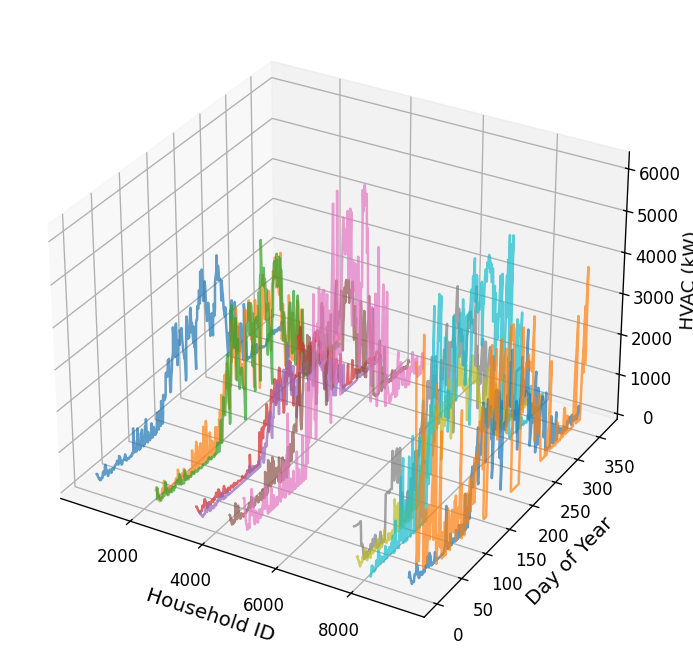

In [7]:
df_all = []
for hh_id, df in datasets_by_hh.items():
    df_time = pd.to_datetime(
        df['localminute'].str[0:16],
        errors='coerce'
    )
    df["day_of_year"] = df_time.dt.dayofyear
    df["hh_id"] = hh_id  # ← make sure hh_id is a column in df_all
    df_all.append(df)

df_all = pd.concat(df_all, ignore_index=True)

# Aggregate per day — use reset_index() to get a proper DataFrame
df_daily = (
    df_all
    .groupby(["hh_id", "day_of_year"])["hvac"]
    .sum()
    .reset_index()  # ← critical fix
)

fig = plt.figure(figsize=(10, 7), dpi=120)
ax = fig.add_subplot(111, projection='3d')

for hh_id in df_daily["hh_id"].unique():
    d = df_daily[df_daily["hh_id"] == hh_id]

    ax.plot(
        [hh_id] * len(d),
        d["day_of_year"],
        d["hvac"],
        alpha=0.7
    )

ax.set_xlabel("Household ID", fontsize=12)
ax.set_ylabel("Day of Year", fontsize=12)
ax.set_zlabel("HVAC (kW)", fontsize=11)
#plt.tight_layout()
#plt.subplots_adjust(right=0.1)   # shrinks the left margin so z-label is visible
plt.savefig("3D_time_series_lines.png")
plt.show()

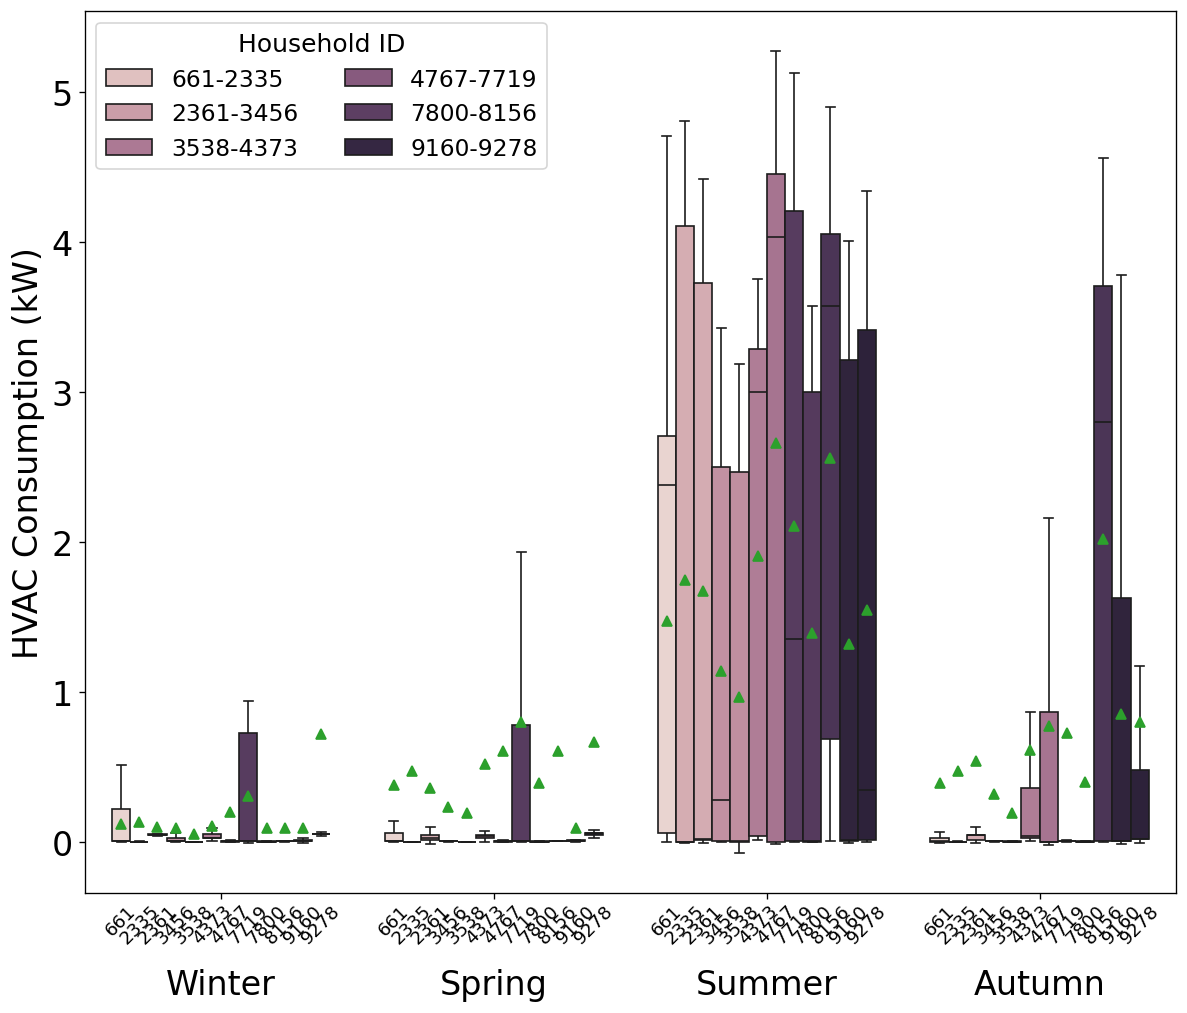

In [8]:
df_all = []

for hh_id, df in datasets_by_hh.items():
    df2 = df.copy()
    df2["hh_id"] = hh_id
    df_all.append(df2)

df_all = pd.concat(df_all, ignore_index=True)

hh_order = ([str(h) for h in datasets_by_hh.keys()])
seasons = ["Winter", "Spring", "Summer", "Autumn"]

n_hh = len(hh_order)
n_seasons = len(seasons)

fig, ax = plt.subplots(figsize=(10, 10), dpi=120)
ax.tick_params(labelsize=20)

sns.boxplot(
    data=df_all,
    hue_order=hh_order,
    x="Season",
    y="hvac",
    hue="hh_id",
    showmeans=True,
    showfliers=False,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
labels =  ["661-2335", 
            "2361-3456",
            "3538-4373", 
            "4767-7719",
            "7800-8156",
            "9160-9278"]
ax.legend(
    handles,
    labels,
    title="Household ID",
    ncol=2,
    fontsize=14,
    title_fontsize=15,
    loc="upper left",
)
#ax.legend_.remove()  # remove the default legend since we're adding custom labels
ax.set_ylabel("HVAC Consumption (kW)", fontsize=20)
ax.set_xlabel("")

# Remove default season tick labels — we'll redraw them lower
ax.set_xticks(range(n_seasons))
ax.set_xticklabels([])  # hide default labels

bar_width = 0.8 / n_hh
offsets = np.linspace(-(n_hh - 1) / 2, (n_hh - 1) / 2, n_hh) * bar_width

# Row 1: HH IDs below each bar
for s_idx in range(n_seasons):
    for h_idx, hh_id in enumerate(hh_order):
        x_pos = s_idx + offsets[h_idx]
        ax.annotate(
            hh_id,
            xy=(x_pos, 0),
            xycoords=("data", "axes fraction"),
            xytext=(0, -5),
            textcoords="offset points",
            ha="center", va="top",
            fontsize=11,          
            rotation=45,
            annotation_clip=False
        )

# Row 2: Season labels below the HH ID row
for s_idx, season in enumerate(seasons):
    ax.annotate(
        season,
        xy=(s_idx, 0),
        xycoords=("data", "axes fraction"),
        xytext=(0, -45),          
        textcoords="offset points",
        ha="center", va="top",
        fontsize=20,
        annotation_clip=False
    )

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # make room for the two label rows
plt.savefig("hvac_consumption_by_season.png", format="png", bbox_inches="tight")